In [33]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Ridge
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

PROCESSED_DIR = Path("../../data/Airbnb Prices in European Cities/processed/")

train_path = PROCESSED_DIR / "barcelona_treino.csv"
test_path = PROCESSED_DIR / "barcelona_teste.csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)


In [34]:

target = "realSum"

X_train = df_train.drop(columns=[target])
y_train = df_train[target]


X_test = df_test.drop(columns=[target])
y_test = df_test[target]

print(df_train.shape)
print(df_test.shape)
print(X_test.shape)


(2266, 13)
(567, 13)
(567, 12)


In [35]:
def analise_hiperparametro(model, features, target):

    param_space = {"alpha": np.logspace(-4, 4, 100),     
                   "fit_intercept": [True, False],
                    "solver": ["auto", "svd"],
                    "positive": [False] }
    
    random_search = RandomizedSearchCV(model, param_space, n_iter=100, cv=5)
    random_search.fit(features, target)
    print("Melhores hiperparâmetros:")
    print(random_search.best_params_)

    return random_search.best_estimator_

def linear_regression(features, target, test_features):
    
    model = Ridge()
    best_model = analise_hiperparametro(model, features, target)
    target_pred = best_model.predict(test_features)

    return target_pred

In [36]:
y_pred = linear_regression(X_train, y_train, X_test)

Melhores hiperparâmetros:
{'solver': 'svd', 'positive': False, 'fit_intercept': True, 'alpha': np.float64(0.9111627561154896)}


In [37]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MSE : 0.0065
RMSE: 0.0809
R²  : 0.5775


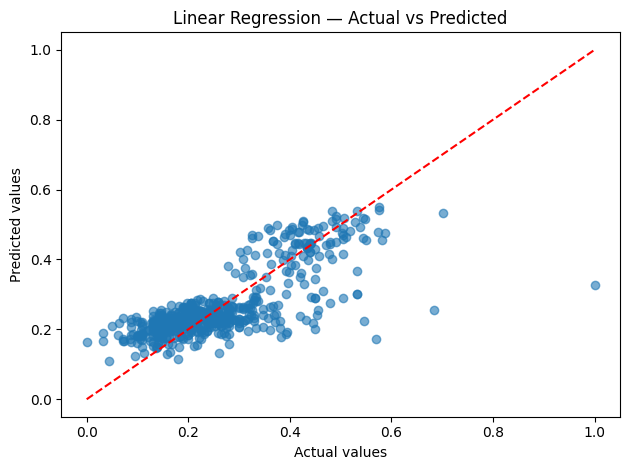

In [38]:
y = df_test['realSum']

plt.scatter(y, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Linear Regression — Actual vs Predicted')
plt.tight_layout()
plt.show()
